## Save Pickle

In [1]:
import os, sys

if "__file__" in globals():
    HERE = os.path.dirname(__file__)
    PROJECT_ROOT = os.path.abspath(os.path.join(HERE, '..'))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
else:
    # Fallback for Jupyter
    PROJECT_ROOT = os.path.abspath("..")
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
from torch.utils.data import DataLoader
from boilerplate.dataloader import SemisupervisedDataset
from tqdm import tqdm
import tifffile as tiff
import torch
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.linalg import norm
from openTSNE import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [25]:
num = "epsSeg - CL"
dir = f"/group/jug/Sheida/HVAE/WACV/{num}/model_supervised/"
sup_or_semi = "sup"
best_checkpoint = dir + "best.net"
patch_size = 64
label_size = 1
mode = 'supervised'
n_classes = 4
batch_size = 1

In [ ]:
data_dir = "/group/jug/Sheida/pancreatic beta cells/download/"
keys = ["high_c1", "high_c2", "high_c3"]
# keys = ["high_c4"]

img_paths = [os.path.join(data_dir + key + f"/{key}_source.tif") for key in keys]
lbl_paths = [os.path.join(data_dir + key + f"/{key}_gt.tif") for key in keys]
imgs = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, img_paths)}
lbls = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, lbl_paths)}
train_idx = {}
np.random.seed(42)
for key in keys:
    # Create a mask for valid indices where labels are not all -1
    # -1 indicates outside of the cell
    
    valid_indices = np.where(~np.all(lbls[key] == -1, axis=(1, 2)))[0]
    total_samples = valid_indices.shape[0]
    np.random.shuffle(valid_indices)  # Shuffles in place

    # Compute split index
    split_idx = int(0.85 * total_samples)

    # Split the indices
    train_idx[key] = valid_indices[:split_idx]

# compute mean and std of the data
all_elements = np.concatenate([imgs[key][train_idx[key]].flatten() for key in keys])
data_mean = np.mean(all_elements)
data_std = np.std(all_elements.astype(np.float32))

# normalizing the data
for key in tqdm(keys, "Normalizing data"):
    imgs[key] = (imgs[key] - data_mean) / data_std

train_set = SemisupervisedDataset(
    images=imgs,
    labels=lbls,
    patch_size=patch_size,
    label_size=label_size,
    mode=mode,
    n_classes=n_classes,
    ignore_lbl=-1,
    indices_dict=train_idx,
)

Normalizing data: 100%|██████████| 3/3 [00:26<00:00,  8.77s/it]


In [ ]:
all_rows = []
model = torch.load(best_checkpoint, weights_only=False)
model.eval()
for anchor_id, batch in tqdm(enumerate(DataLoader(train_set, batch_size=batch_size)), desc="Evaluating on training set"):

    group = train_set.groups[anchor_id]  # dict with keys: name, z, coords, labels
    name   = group['name']
    z_idx  = group['z']
    coords = group['coords']   # list of 8 (y,x)
    group_labels = group['labels']   # list of 8

    
    labels = batch[1].view(-1,1).squeeze(-1).to(device)
    batch = batch[0].float().squeeze(0).to(device)
    with torch.no_grad():
        model.mode_pred = True
        model.eval()
        output = model(batch)

        pi = output['pi']               # (8,4)
        mus = output['mu']             # list of 3 tensors
        z   = torch.cat(
                [F.adaptive_avg_pool2d(x, (1,1)).flatten(1) for x in mus],
                dim=1
            )                          # (8,latent_dim)
        z   = F.normalize(z, dim=1)

        for n in range(1):
            row = {
                'anchor_id': anchor_id,
                'name'     : name,
                'z'        : z_idx,
                'y'        : coords[n][0],
                'x'        : coords[n][1],
                'label'    : group_labels[n],
                'neighbor_index': n,
                'pi'       : pi[n].detach().cpu().numpy(),    # (4,)
                'latent'        : z[n].detach().cpu().numpy(),     # (latent,)
            }
            all_rows.append(row)

# 5. --> DataFrame --> pickle
df = pd.DataFrame(all_rows)
df.to_pickle(dir+"dataset_"+sup_or_semi+".pkl")
print("saved to dataset.pkl")


Evaluating on training set: 10029it [09:07, 18.31it/s]


saved to dataset.pkl


In [20]:
# 1. Load dataframe
df = pd.read_pickle(dir+"dataset_"+sup_or_semi+".pkl")

# 2. Compute predicted label = argmax(pi)
df["pred_label"] = df["pi"].apply(lambda p: np.argmax(p))

# 3. Save it back (overwrite or new file)
df.to_pickle(dir+"dataset_with_pred_"+sup_or_semi+".pkl")

print("✅ Added 'pred_label' and saved to dataset_with_pred.pkl")
print(df.head())


✅ Added 'pred_label' and saved to dataset_with_pred.pkl
   anchor_id     name    z    y    x  label  neighbor_index  \
0          0  high_c1  564  492  239      0               0   
1          1  high_c1  564  520  417      2               0   
2          2  high_c1  564  340  575      3               0   
3          3  high_c1  392  331  495      0               0   
4          4  high_c1  392  243  241      2               0   

                                                 pi  \
0  [0.32182124, 0.17915148, 0.28949487, 0.20953244]   
1  [0.40528327, 0.16187942, 0.15125437, 0.28158298]   
2  [0.6191912, 0.11105281, 0.16669282, 0.103063114]   
3   [0.3148356, 0.22325203, 0.24060573, 0.22130667]   
4   [0.37989482, 0.1610498, 0.18236172, 0.27669367]   

                                              latent  pred_label  
0  [-0.047352914, -0.022033265, -0.030586474, -0....           0  
1  [-0.008704818, -0.0031521416, -0.00090926903, ...           0  
2  [-0.017492322, -0.0031493632, 

## Load Pickle

In [21]:
df = pd.read_pickle(dir+"dataset_with_pred_"+sup_or_semi+".pkl")
anchors = df[df['neighbor_index'] == 0]  # only anchors
# neighbours = df[df['neighbor_index'] != 0]  # only neighbours
Z_anchors = np.vstack(anchors['latent'].values)  # (N, latent_dim)
# Z_neighbours = np.vstack(neighbours['latent'].values)   # (N, latent_dim)
Z = np.vstack(df['latent'].values)   # (N, latent_dim)

label_anchor = anchors['label'].values     # (N,)
# label_neighbour = neighbours['label'].values  # (N,)
pred_anchor = anchors['pred_label'].values  # (N,)
# pred_neighbour = neighbours['pred_label'].values  # (N,)
labels = df['label'].values     # (N,)
pred = df['pred_label'].values  # (N,)
label_names = {0: 'unrecognized', 1: 'nucleus', 2: 'granules', 3: 'mitochondria'}

In [22]:
save_plot_dir = dir + "plot_" + sup_or_semi + "/"
os.makedirs(save_plot_dir, exist_ok=True)

In [23]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    verbose=True,
)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 1.97 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.15 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=835.75 for 250 iterations...
Iteration   50, KL divergence 3.9612, 50 iterations in 0.6663 sec
Iteration  100, KL divergence 3.8220, 50 iterations in 0.6758 sec
Iteration  150, KL divergence 3.7738, 50 iterations in 0.6550 sec
Iteration  200, KL divergence 3.7531, 50 iterations in 0.6571 sec
Iteration  250, KL divergence 3.7408, 50 iterations in 0.6555 sec
   --> Time elapsed: 3.31 seconds
===> Running optimization with exaggeration=1.

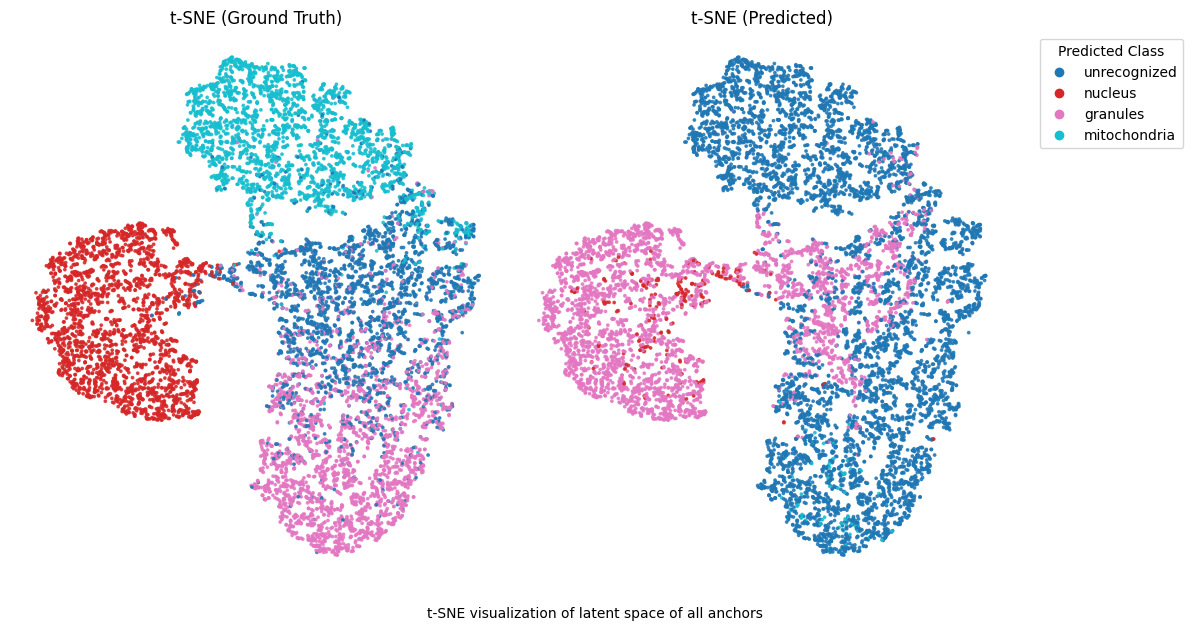

In [24]:
%time Y = tsne.fit(Z_anchors)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all anchors", 
         ha='center', va='top', fontsize=10)
cmap_used = sc.cmap
norm_used = sc.norm
plt.tight_layout()
plt.show()
fig.savefig(save_plot_dir+"tsne_anchors.png", dpi=300, bbox_inches="tight")

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 3.68 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.32 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=1793.17 for 250 iterations...
Iteration   50, KL divergence 4.7856, 50 iterations in 1.0088 sec
Iteration  100, KL divergence 4.5787, 50 iterations in 0.9955 sec
Iteration  150, KL divergence 4.5001, 50 iterations in 0.9855 sec
Iteration  200, KL divergence 4.4680, 50 iterations in 0.9743 sec
Iteration  250, KL divergence 4.4499, 50 iterations in 0.9951 sec
   --> Time elapsed: 4.96 seconds
===> Running optimization with exaggeration=1

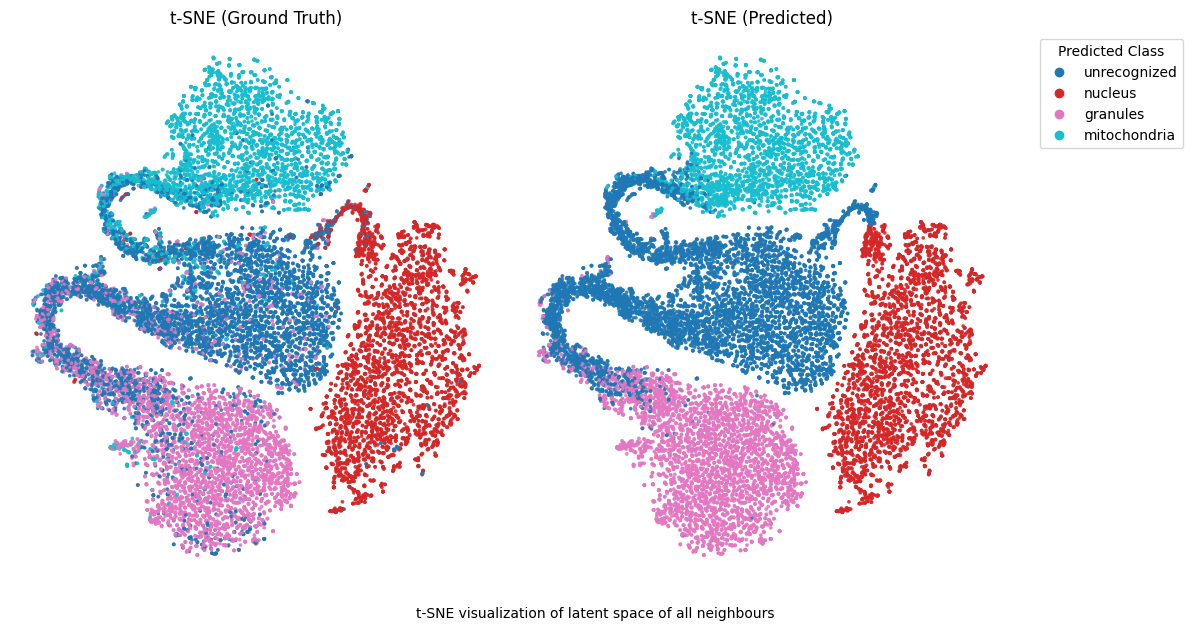

In [43]:
%time Y = tsne.fit(Z_neighbours)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all neighbours", 
         ha='center', va='top', fontsize=10)
# cmap_used = sc.cmap
# norm_used = sc.norm

plt.tight_layout()
plt.show()
fig.savefig(save_plot_dir+"tsne_all.png", dpi=300, bbox_inches="tight")

In [44]:
unrec = anchors[anchors['label'] == 0]  # unrecognized anchors
TP_unrec = unrec[unrec['label'] == unrec['pred_label']]  # True Positives 
neighbours_unrec = neighbours[neighbours['anchor_id'].isin(TP_unrec['anchor_id'])]  # neighbours of TP unrecognized anchors

nuc = anchors[anchors['label'] == 1]  # nucleus anchors
TP_nuc = nuc[nuc['label'] == nuc['pred_label']]  # True Positives 
neighbours_nuc = neighbours[neighbours['anchor_id'].isin(TP_nuc['anchor_id'])]  # neighbours of TP nucleus anchors

granules = anchors[anchors['label'] == 2]  # granules anchors
TP_granules = granules[granules['label'] == granules['pred_label']]  # True Positives 
neighbours_granules = neighbours[neighbours['anchor_id'].isin(TP_granules['anchor_id'])]  # neighbours of TP granules anchors

mito = anchors[anchors['label'] == 3]  # mitochondria anchors
TP_mito = mito[mito['label'] == mito['pred_label']]  # True Positives 
neighbours_mito = neighbours[neighbours['anchor_id'].isin(TP_mito['anchor_id'])]  # neighbours of TP mitochondria anchors

TP_anchors = pd.concat([TP_unrec, TP_nuc, TP_granules, TP_mito], ignore_index=True)

In [45]:
tsne_colors = {i: cmap_used(norm_used(i)) for i in range(4)}

# For seaborn (string keys usually safer)
palette_tsne = {str(i): tsne_colors[i] for i in tsne_colors}

In [46]:
def analyze_neighbours(neighbours_df, TP_anchors, class_label, class_name):
    """
    neighbours_df: dataframe of neighbours for the chosen TP anchors
    TP_anchors: dataframe of all TP anchors (for distance computation)
    class_label: int (0..3) for the class being analyzed
    class_name: str for pretty plot titles
    """
    total = len(neighbours_df)
    fig = plt.figure(figsize=(15,5))
    # 1. Distribution of true labels
    ax1 = plt.subplot(1,3,1)
    ax2 = plt.subplot(1,3,2)
    ax3 = plt.subplot(1,3,3)

    # 3. Distribution of closest-anchor labels in latent space
    anchor_latents = np.vstack(TP_anchors['latent'].values)

    closest_labels = []
    latent_dists = []

    for _, row in neighbours_df.iterrows():
        vec = row['latent']
        closest_idx = np.argmin(norm(anchor_latents - vec, axis=1))
        closest_labels.append(TP_anchors.iloc[closest_idx]['label'])

        # store distances for later
        latent_dists.append(norm(anchor_latents[closest_idx] - vec))

    neighbours_df['closest_anchor_label'] = closest_labels
    
    sns.countplot(x='label', data=neighbours_df, palette=palette_tsne,
              order=[0,1,2,3], stat='percent', ax=ax1)
    sns.countplot(x='pred_label', data=neighbours_df, palette=palette_tsne,
                order=[0,1,2,3], stat='percent', ax=ax2)
    sns.countplot(x='closest_anchor_label', data=neighbours_df, palette=palette_tsne,
                order=[0,1,2,3], stat='percent', ax=ax3)

    for ax in (ax1, ax2, ax3):
        ax.set_ylim(0, 100)  # percent scale
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.set_ylabel('')
        for p in ax.patches:
            h = p.get_height()           
            ax.annotate(f"{h:.1f}%",
                        (p.get_x() + p.get_width()/2., h),
                        ha='center', va='bottom', fontsize=9)
        for s in ['top','right','bottom','left']:
            ax.spines[s].set_visible(True)
        ax.set_xticks(range(4))
        ax.set_xticklabels([label_names[i] for i in range(4)])
        
    ax1.set_title(f"True labels of neighbours of TP {class_name} anchors")
    ax2.set_title(f"Predicted labels of neighbours of TP {class_name} anchors")
    ax3.set_title(f"Closest TP anchor labels (latent space)")
    

    plt.tight_layout()
    plt.show()
    fig.savefig(save_plot_dir+"analyze_neighbours_"+str(class_label)+".png", dpi=300, bbox_inches="tight")

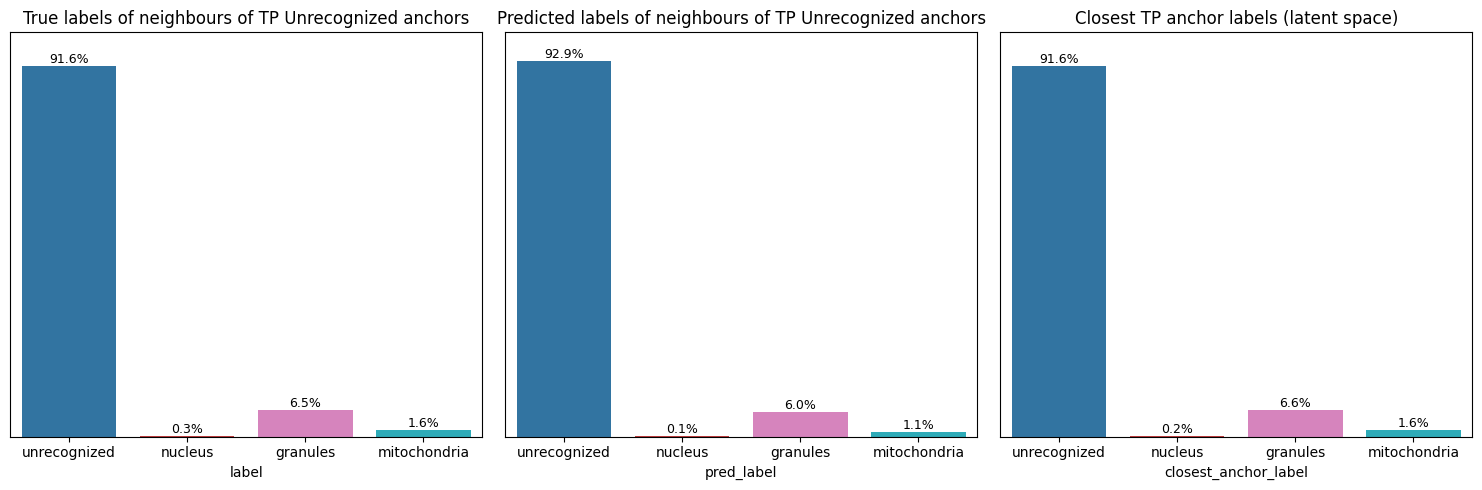

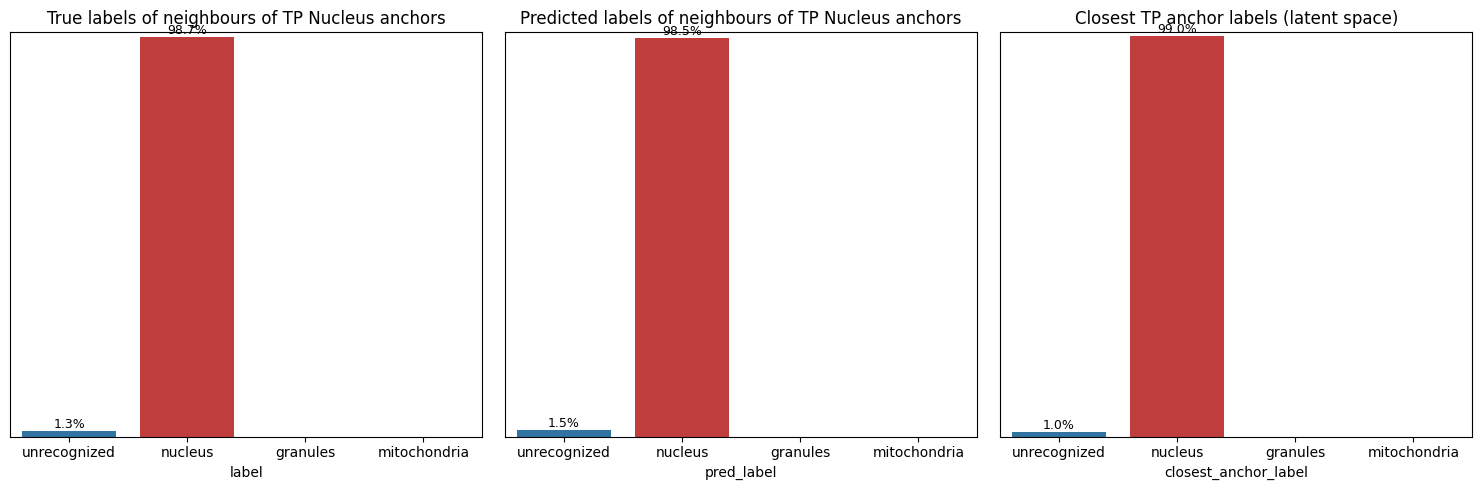

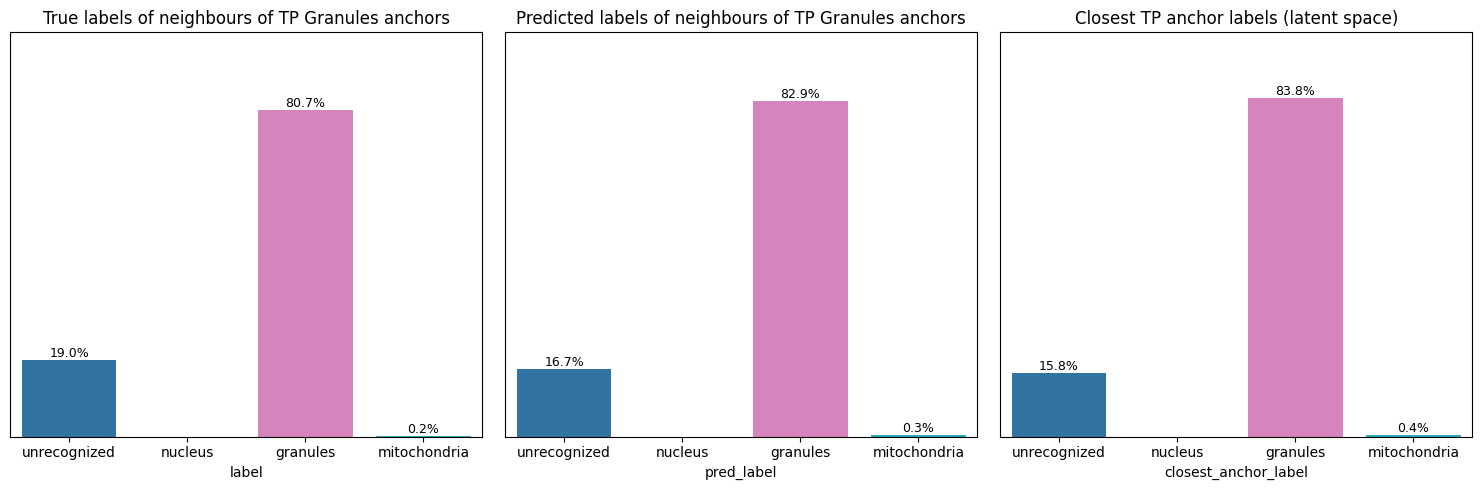

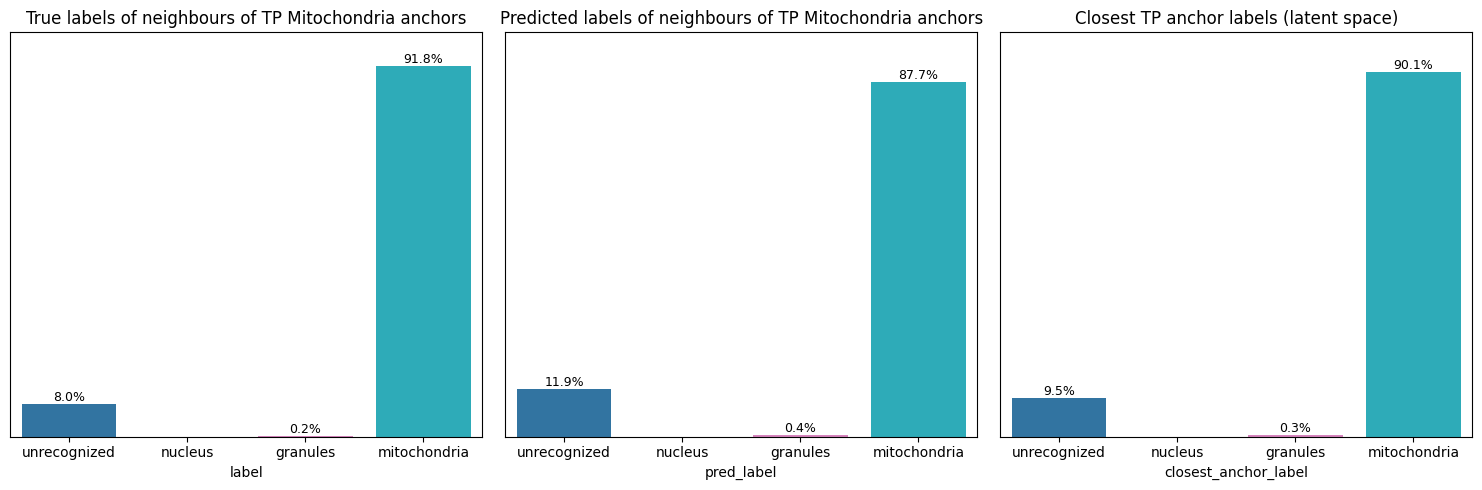

In [47]:
analyze_neighbours(neighbours_unrec, TP_anchors, 0, "Unrecognized")
analyze_neighbours(neighbours_nuc, TP_anchors, 1, "Nucleus")
analyze_neighbours(neighbours_granules, TP_anchors, 2, "Granules")
analyze_neighbours(neighbours_mito, TP_anchors, 3, "Mitochondria")

In [48]:
# Build NN index on TP anchors (latent)
TP_anchor_latents = np.vstack(TP_anchors['latent'].values).astype(np.float32)
TP_anchor_labels  = TP_anchors['label'].values
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(TP_anchor_latents)

NearestNeighbors(metric='euclidean', n_neighbors=1)

In [49]:
def latent_distance_distribution(neighbours_df, title=""):

    # --- Neighbour latents & closest TP anchor in latent ---
    neigh_latents = np.vstack(neighbours_df['latent'].values).astype(np.float32)
    dists, idxs = nn.kneighbors(neigh_latents, return_distance=True)
    dists = dists.ravel(); idxs = idxs.ravel()
    closest_anchor_labels = TP_anchor_labels[idxs]
    # check which neghbour's label we predict like closest anchor label

    tmp = neighbours_df.copy()
    tmp['closest_latent_dist']  = dists
    tmp['closest_anchor_label'] = closest_anchor_labels

    # distance to each neighbour's own reference TP anchor
    tp_map = dict(zip(TP_anchors['anchor_id'].values, TP_anchors['latent'].values))
    tmp['own_anchor_latent_dist'] = [
        norm(r['latent'] - tp_map[r['anchor_id']]) for _, r in neighbours_df.iterrows()
    ]

    s = tmp['own_anchor_latent_dist']
    print("min:", s.min(), "max:", s.max())
    print("any negative?", (s < 0).any())

    # if you want to see offending rows (should be none)
    bad = tmp[s < 0]
    print("n negative:", len(bad))
    print(bad.head())

    # optional: also check NaNs / infs and enforce a tiny tolerance
    print("has NaN?", s.isna().any(), "has inf?", np.isinf(s.to_numpy()).any())
    eps = 1e-12
    assert not (s < -eps).any(), f"Found {(s < -eps).sum()} distances < -{eps}"

    # colors
    c_closest = "forestgreen"
    c_own     = "darkorange"
    cmap_fallback = plt.get_cmap("tab10")
    palette_local = {str(i): (palette_tsne[str(i)] if 'palette_tsne' in globals() else cmap_fallback(i))
                     for i in range(4)}

    # ---- PLOTS ----
    fig = plt.figure(figsize=(10,4))
    ax1 = plt.subplot(1,2,1)

    # --- compute means first
    mu_closest = float(np.mean(tmp['closest_latent_dist']))
    mu_own     = float(np.mean(tmp['own_anchor_latent_dist']))

    # KDEs with μ in legend
    sns.kdeplot(tmp['closest_latent_dist'], ax=ax1, linewidth=2, color=c_closest,
                label=rf"to closest anchor ($\mu$={mu_closest:.3f})")
    sns.kdeplot(tmp['own_anchor_latent_dist'], ax=ax1, linewidth=2, color=c_own,
                label=rf"to reference anchor ($\mu$={mu_own:.3f})")

    # guide lines (no text on plot)
    ax1.axvline(mu_closest, color=c_closest, lw=1.6, ls='--', alpha=0.9)
    ax1.axvline(mu_own,     color=c_own,     lw=1.6, ls='--', alpha=0.9)

    ax1.set_title(f"Latent distance distribution\n{title}")
    ax1.legend(frameon=True, framealpha=0.95)

    # Panel 2: by label of closest TP anchor (each label’s μ in legend)
    ax2 = plt.subplot(1,2,2)
    order = [0,1,2,3]
    for lab in order:
        vals = tmp.loc[tmp['closest_anchor_label']==lab, 'closest_latent_dist'].values
        if len(vals) == 0:
            continue
        color = palette_local[str(lab)]
        m = float(np.mean(vals))
        sns.kdeplot(vals, ax=ax2, linewidth=2, color=color,
                    label=rf"{label_names[lab]} ($\mu$={m:.3f})")
        ax2.axvline(m, color=color, lw=1.4, ls='--', alpha=0.9)

    ax2.set_title("Latent distance distribution\nto the closest anchor label")
    ax2.legend(title="Closest anchor", frameon=True, framealpha=0.95)
    # for one axis
    ax1.set_xlabel(None)
    ax1.set_ylabel(None)

    # do the same for ax2
    ax2.set_xlabel(None)
    ax2.set_ylabel(None)
    plt.tight_layout()
    plt.show()
    fig.savefig(save_plot_dir+"latent_distance_distribution_"+title+".png", dpi=300, bbox_inches="tight")
    return tmp[['closest_latent_dist','own_anchor_latent_dist','closest_anchor_label']]


In [50]:
def latent_distance_violin(neighbours_df, title=""):
    # --- Neighbour latents & closest TP anchor in latent ---
    neigh_latents = np.vstack(neighbours_df['latent'].values).astype(np.float32)
    dists, idxs = nn.kneighbors(neigh_latents, return_distance=True)
    dists = dists.ravel(); idxs = idxs.ravel()
    closest_anchor_labels = TP_anchor_labels[idxs]

    tmp = neighbours_df.copy()
    tmp['closest_latent_dist']  = dists
    tmp['closest_anchor_label'] = closest_anchor_labels

    # distance to each neighbour's own reference TP anchor
    tp_map = dict(zip(TP_anchors['anchor_id'].values, TP_anchors['latent'].values))
    tmp['own_anchor_latent_dist'] = [
        norm(r['latent'] - tp_map[r['anchor_id']]) for _, r in neighbours_df.iterrows()
    ]

    # ---- colors/palette ----

    cmap_fallback = plt.get_cmap("tab10")
    palette_local = {str(i): (palette_tsne[str(i)] if 'palette_tsne' in globals() else cmap_fallback(i))
                     for i in range(4)}
    order = [0,1,2,3]

    # ===== PLOTS: 1×3 =====
    fig, (ax2, ax3) = plt.subplots(
        1, 2, figsize=(10,4), gridspec_kw={'width_ratios':[1,1]}
    )

    # (2) per-class KDE (by closest-anchor label)
    for lab in order:
        vals = tmp.loc[tmp['closest_anchor_label']==lab, 'closest_latent_dist'].values
        if len(vals) == 0: continue
        color = palette_local[str(lab)]
        m = float(np.mean(vals))
        sns.kdeplot(vals, ax=ax2, linewidth=2, color=color,
                    label=rf"{label_names[lab]} ($\mu$={m:.3f})")
        ax2.axvline(m, color=color, lw=1.4, ls='--', alpha=0.9)
    ax2.set_title("Latent distance to the closest anchor label")
    ax2.set_xlabel(None); ax2.set_ylabel(None)
    ax2.legend(title="Closest anchor", frameon=True, framealpha=0.95)

    # (3) split violin: does GT match the closest-anchor label?
    tmp['is_match'] = np.where(tmp['label']==tmp['closest_anchor_label'], 'match', 'mismatch')
    # ensure both hue levels exist so split=True works nicely
    tmp['is_match'] = pd.Categorical(tmp['is_match'], categories=['match','mismatch'])

    sns.violinplot(
        data=tmp, x='closest_anchor_label', y='closest_latent_dist',
        order=order,
        hue='is_match', hue_order=['match','mismatch'],
        split=True, inner='quart', cut=0, bw_method='scott',
        palette={'match':'forestgreen', 'mismatch':'crimson'},
        ax=ax3
    )
    ax3.set_xticklabels([label_names[i] for i in order], rotation=0)
    ax3.set_title("Closest distance split by GT==closest?")
    ax3.set_xlabel(None); ax3.set_ylabel(None)
    ax3.legend(title='GT vs closest', bbox_to_anchor=(1.02,1), loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()
    fig.savefig(save_plot_dir+"latent_distance_violin_"+title+".png", dpi=300, bbox_inches="tight")


In [51]:
def latent_distance_bar(neighbours_df, title="Per-class latent distance distributions",
                           bins=30, bw_method="scott", show_means=True):
    """
    For each class (0–3):
      - stacked histogram of closest_latent_dist (red = mismatch, green = match), normalized to density
      - TWO KDEs: green for matches, red for mismatches
      - optional mean lines for each subset

    Layout: 3×2 grid (up to 6 slots: 4 classes + violin panel).
    """
    # --- Compute closest anchors ---
    neigh_latents = np.vstack(neighbours_df['latent'].values).astype(np.float32)
    dists, idxs = nn.kneighbors(neigh_latents, return_distance=True)
    dists = dists.ravel()
    idxs  = idxs.ravel()
    closest_anchor_labels = TP_anchor_labels[idxs]

    tmp = neighbours_df.copy()
    tmp['closest_latent_dist']  = dists
    tmp['closest_anchor_label'] = closest_anchor_labels

    tp_map = dict(zip(TP_anchors['anchor_id'].values, TP_anchors['latent'].values))
    tmp['own_anchor_latent_dist'] = [
        norm(r['latent'] - tp_map[r['anchor_id']]) for _, r in neighbours_df.iterrows()
    ]

    tmp['is_match'] = np.where(tmp['label'] == tmp['closest_anchor_label'], 'match', 'mismatch')
    tmp['is_match'] = pd.Categorical(tmp['is_match'], categories=['match', 'mismatch'])

    # ---- palette ----
    cmap_fallback = plt.get_cmap("tab10")
    order = [0, 1, 2, 3]
    palette_local = {
        str(i): (palette_tsne[str(i)] if 'palette_tsne' in globals() else cmap_fallback(i))
        for i in order
    }

    # ===== PLOTS: 3×2 grid =====
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    if title:
        fig.suptitle(title, y=1.02, fontsize=14)

    # shared bins across classes
    max_d = float(tmp['closest_latent_dist'].max()) if len(tmp) else 1.0
    if np.isscalar(bins):
        bins = np.linspace(0.0, max(1e-8, max_d), int(bins))
    bin_width = bins[1] - bins[0]
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # -------- PER CLASS PANELS --------
    for j, lab in enumerate(order):
        ax = axes[j]
        sub = tmp.loc[tmp['closest_anchor_label'] == lab]
        if sub.empty:
            ax.set_visible(False)
            continue

        vals_all      = sub['closest_latent_dist'].values
        vals_match    = sub.loc[sub['is_match'] == 'match', 'closest_latent_dist'].values
        vals_mismatch = sub.loc[sub['is_match'] == 'mismatch', 'closest_latent_dist'].values

        cnt_mis, _ = np.histogram(vals_mismatch, bins=bins)
        cnt_mat, _ = np.histogram(vals_match,    bins=bins)
        n = len(vals_all)

        dens_mis = cnt_mis / (n * bin_width) if n > 0 else cnt_mis
        dens_mat = cnt_mat / (n * bin_width) if n > 0 else cnt_mat

        # stacked bars
        ax.bar(bin_centers, dens_mis, width=bin_width, align='center',
               alpha=0.35, color='crimson', edgecolor='none')
        ax.bar(bin_centers, dens_mat, width=bin_width, align='center',
               alpha=0.35, color='forestgreen', edgecolor='none', bottom=dens_mis)

        # # two KDEs
        # if len(vals_mismatch) >= 2:
        #     sns.kdeplot(vals_mismatch, ax=ax, linewidth=2, color='crimson',
        #                 bw_method=bw_method)
        # if len(vals_match) >= 2:
        #     sns.kdeplot(vals_match, ax=ax, linewidth=2, color='forestgreen',
        #                 bw_method=bw_method)

        if show_means and len(vals_mismatch) > 0:
            ax.axvline(np.mean(vals_mismatch), color='crimson', lw=1.4, ls='--', alpha=0.9)
        if show_means and len(vals_match) > 0:
            ax.axvline(np.mean(vals_match), color='forestgreen', lw=1.4, ls='--', alpha=0.9)

        ax.set_title(f"{label_names[lab]}")
        ax.set_xlabel("Latent distance")
        ax.set_ylabel("Density")

    

    plt.tight_layout()
    plt.show()
    fig.savefig(save_plot_dir+"latent_distance_bar_"+title+".png", dpi=300, bbox_inches="tight")



min: 0.007208443 max: 0.8797873
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


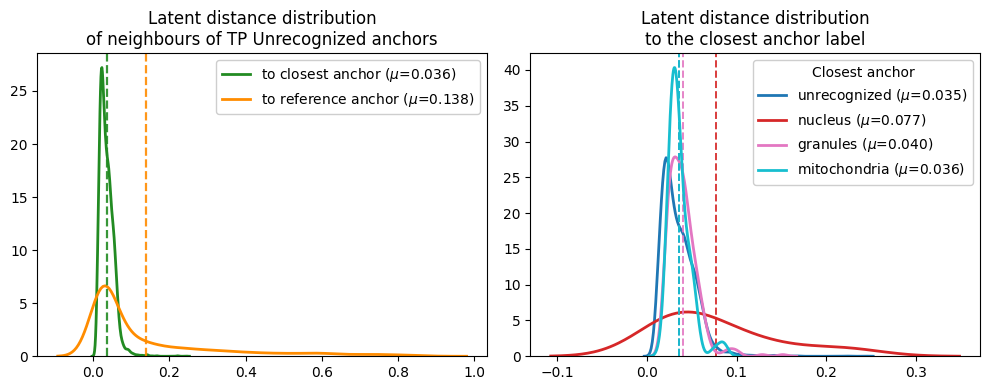

% neighbors whose own anchor is the closest in latent: 35.6%
% neighbors whose closest anchor (latent) is from unrecognized class: 91.6%


In [52]:
unrec_tmp = latent_distance_distribution(neighbours_unrec, title="of neighbours of TP Unrecognized anchors")
own_is_closest = (unrec_tmp['own_anchor_latent_dist'] <= unrec_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (unrec_tmp['closest_anchor_label'] == 0).mean()
print(f"% neighbors whose closest anchor (latent) is from unrecognized class: {prop_closest_unrec:.1%}")

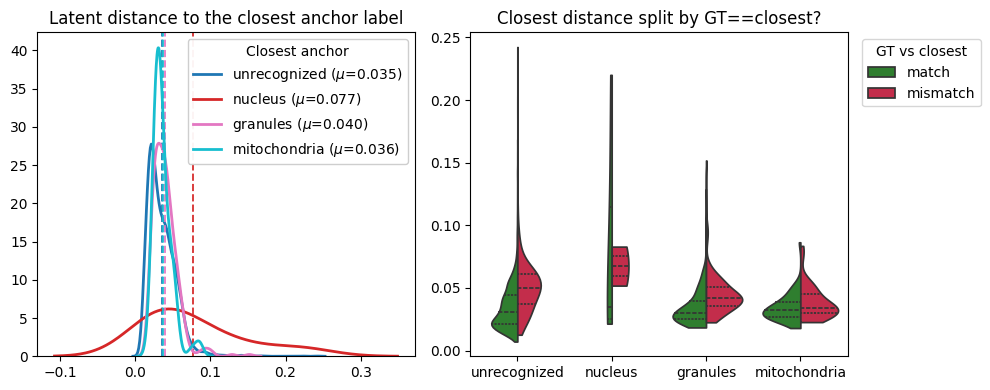

In [53]:
latent_distance_violin(neighbours_unrec, title="of neighbours of TP Unrecognized anchors")

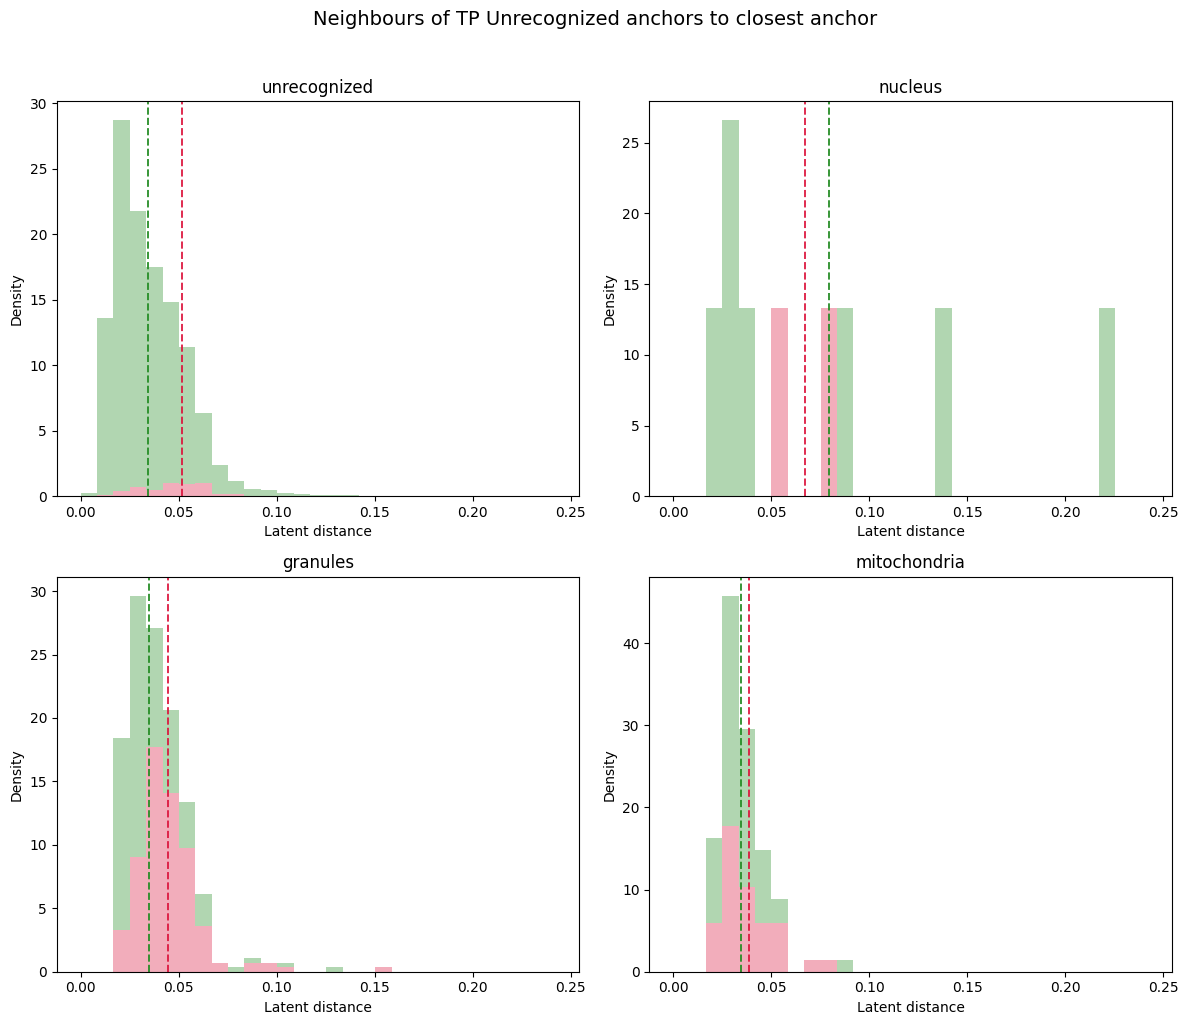

In [54]:
latent_distance_bar(neighbours_unrec, title="Neighbours of TP Unrecognized anchors to closest anchor")

min: 0.004014175 max: 0.8547822
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


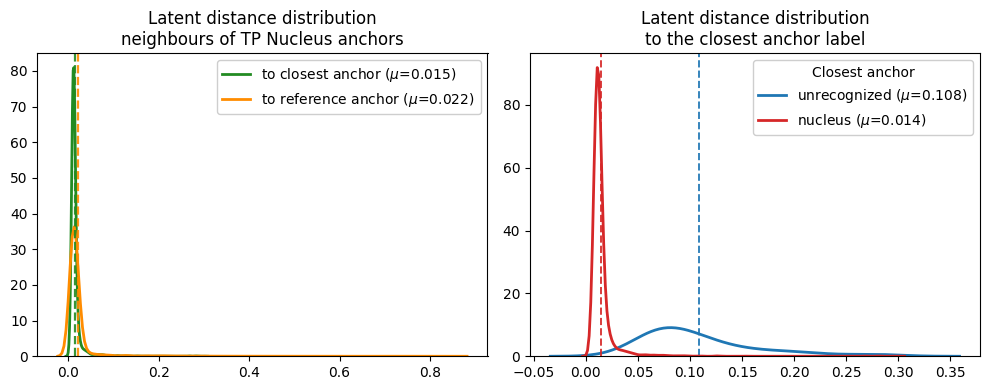

% neighbors whose own anchor is the closest in latent: 63.8%
% neighbors whose closest anchor (latent) is from nucleus class: 99.0%


In [55]:
nuc_tmp = latent_distance_distribution(neighbours_nuc, title="neighbours of TP Nucleus anchors")
own_is_closest = (nuc_tmp['own_anchor_latent_dist'] <= nuc_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (nuc_tmp['closest_anchor_label'] == 1).mean()
print(f"% neighbors whose closest anchor (latent) is from nucleus class: {prop_closest_unrec:.1%}")

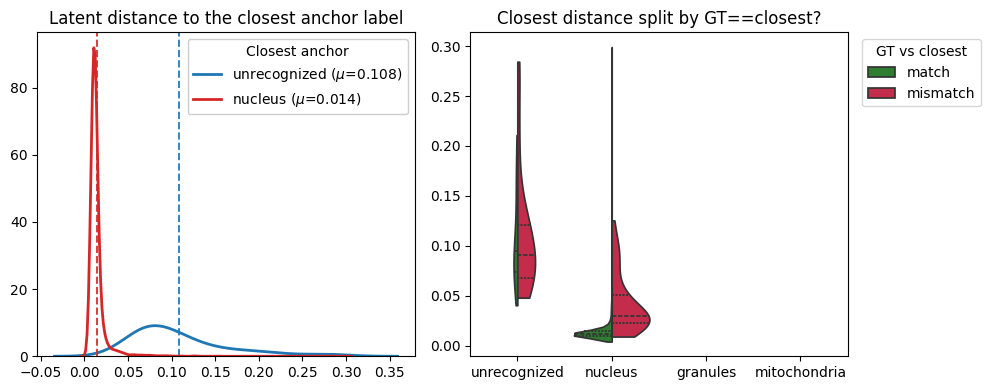

In [56]:
latent_distance_violin(neighbours_nuc, title="neighbours of TP Nucleus anchors")

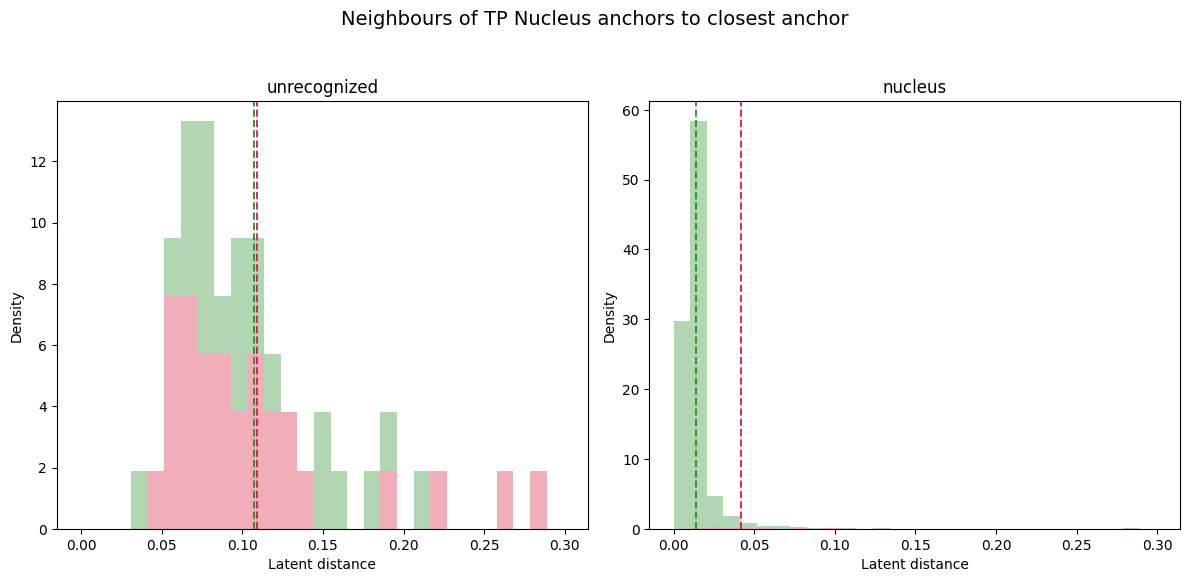

In [57]:
latent_distance_bar(neighbours_nuc, title="Neighbours of TP Nucleus anchors to closest anchor")

min: 0.004599727 max: 0.9438396
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


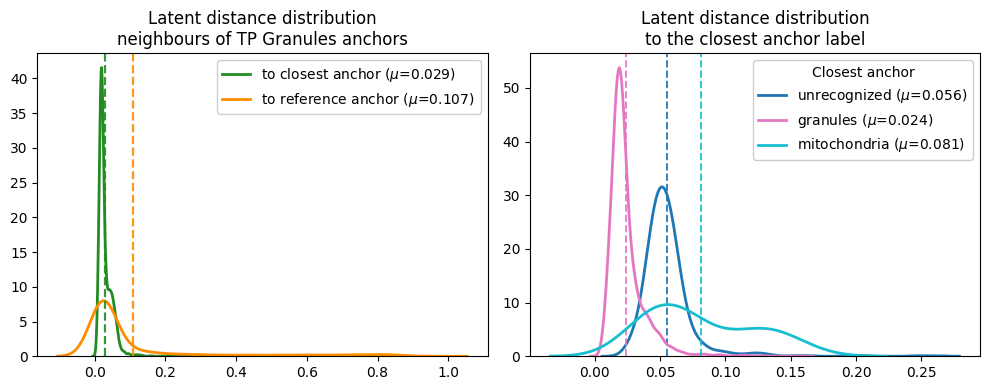

% neighbors whose own anchor is the closest in latent: 42.3%
% neighbors whose closest anchor (latent) is from granules class: 83.8%


In [58]:
gra_tmp = latent_distance_distribution(neighbours_granules, title="neighbours of TP Granules anchors")
own_is_closest = (gra_tmp['own_anchor_latent_dist'] <= gra_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (gra_tmp['closest_anchor_label'] == 2).mean()
print(f"% neighbors whose closest anchor (latent) is from granules class: {prop_closest_unrec:.1%}")

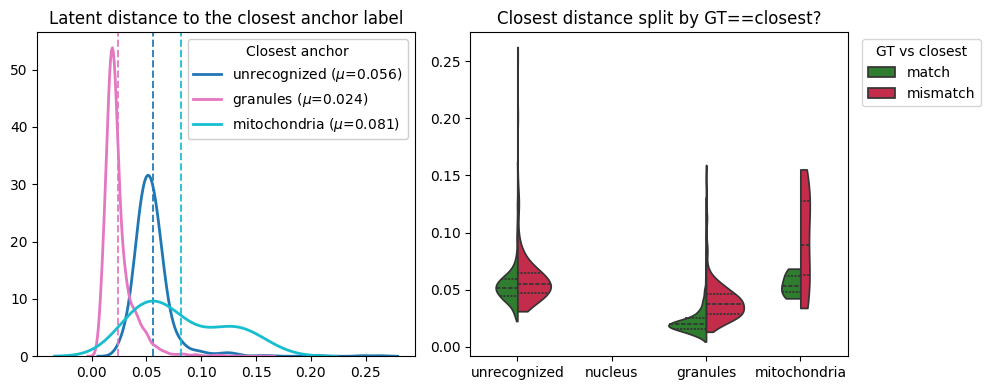

In [59]:
latent_distance_violin(neighbours_granules, title="neighbours of TP Granules anchors")

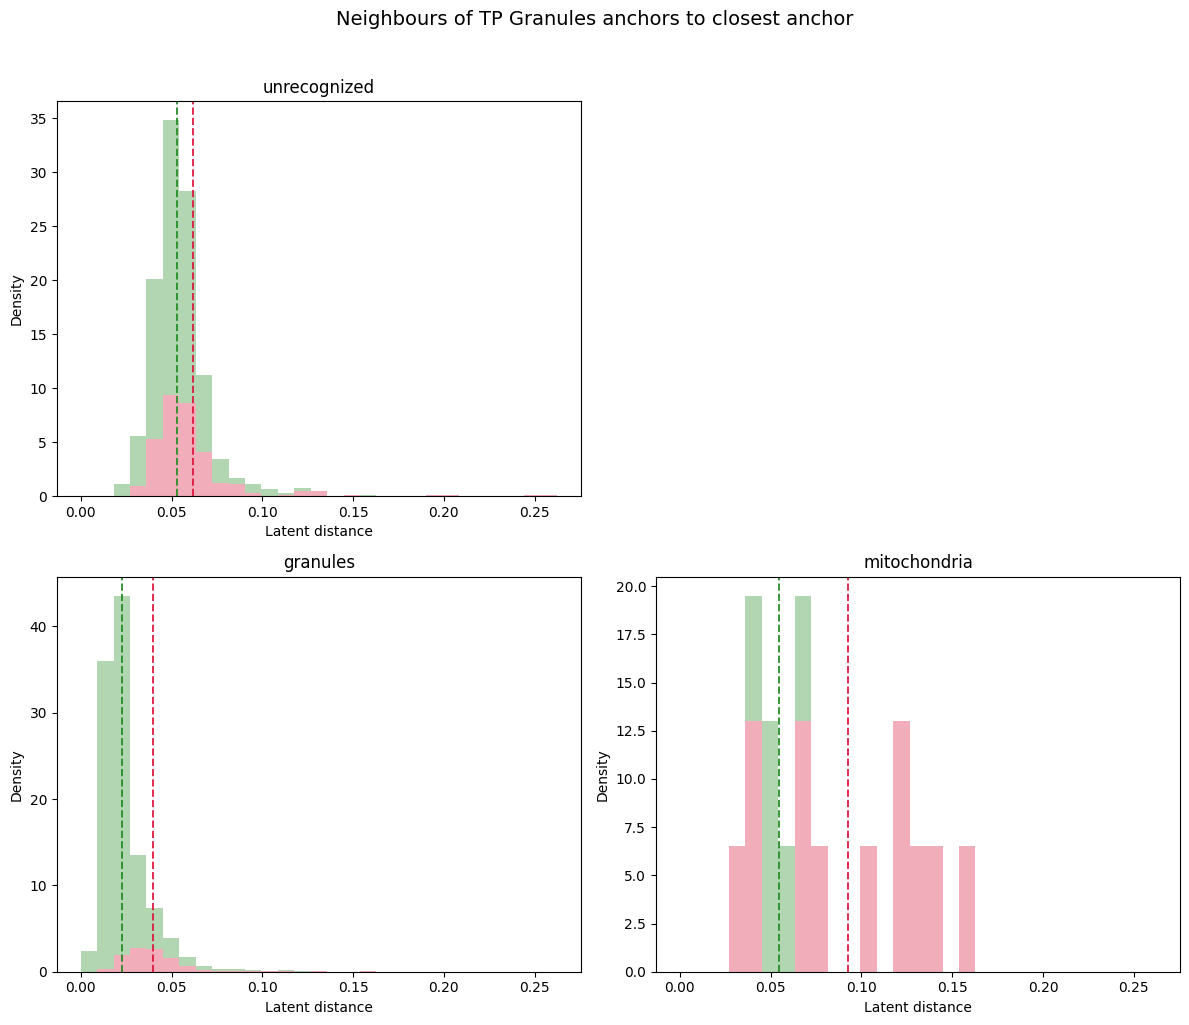

In [60]:
latent_distance_bar(neighbours_granules, title="Neighbours of TP Granules anchors to closest anchor")

min: 0.0044141584 max: 0.9246394
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


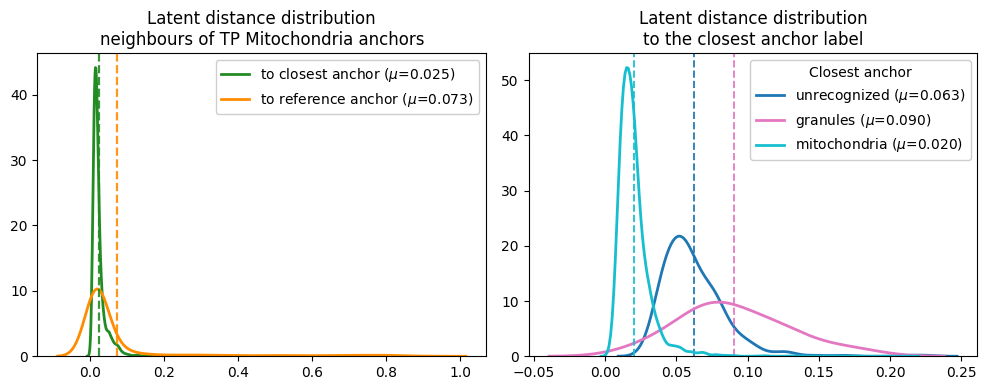

% neighbors whose own anchor is the closest in latent: 55.9%
% neighbors whose closest anchor (latent) is from mitochondria class: 90.1%


In [61]:
mito_tmp = latent_distance_distribution(neighbours_mito, title="neighbours of TP Mitochondria anchors")
own_is_closest = (mito_tmp['own_anchor_latent_dist'] <= mito_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (mito_tmp['closest_anchor_label'] == 3).mean()
print(f"% neighbors whose closest anchor (latent) is from mitochondria class: {prop_closest_unrec:.1%}")

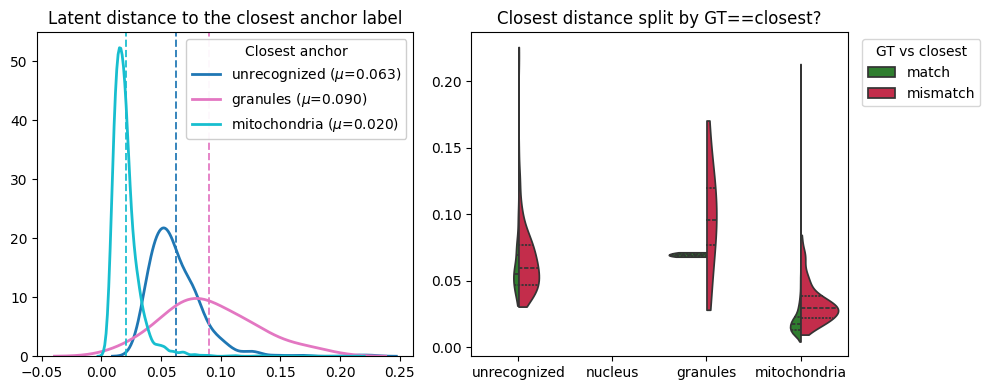

In [62]:
latent_distance_violin(neighbours_mito, title="neighbours of TP Mitochondria anchors")


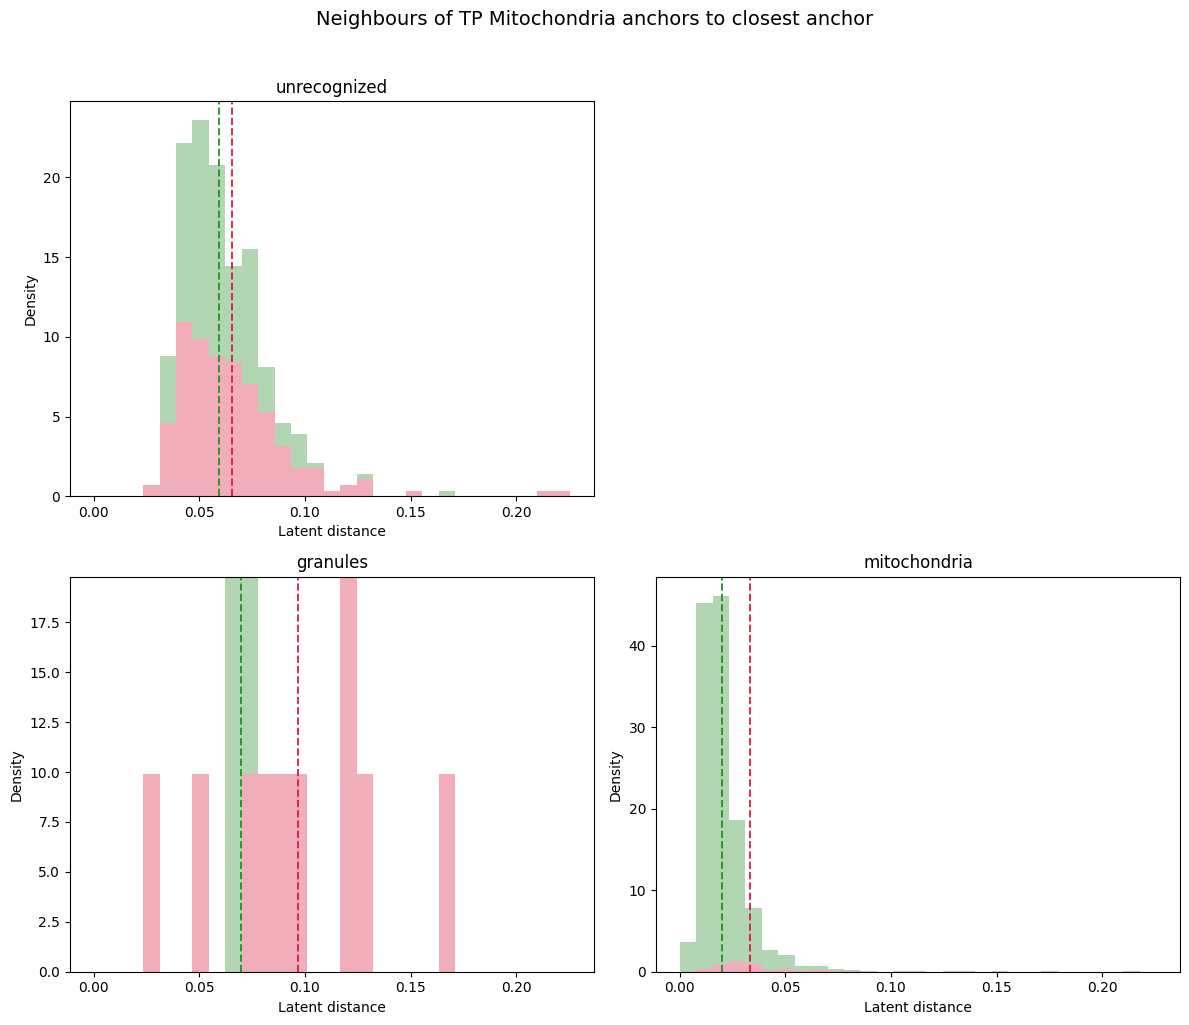

In [63]:
latent_distance_bar(neighbours_mito, title="Neighbours of TP Mitochondria anchors to closest anchor")

In [64]:
def describe(v):
    v = np.asarray(v)
    return {
        "n_pairs": len(v),
        "min": float(np.min(v)),
        "median": float(np.median(v)),
        "mean": float(np.mean(v)),
        "p95": float(np.percentile(v, 95)),
    }
def plot_pairwise_latent_distances(d_lat, lbl):
    """
    d_lat: array of pairwise distances in latent space
    """
    fig, ax = plt.subplots(figsize=(6,4))
    c0 = (palette_tsne[str(lbl)] if 'palette_tsne' in globals() else plt.get_cmap('tab10')(lbl))

    sns.histplot(d_lat, bins=60, kde=True, color=c0, ax=ax)
    ax.axvline(np.mean(d_lat),   ls='--', lw=1.2, color='k', alpha=0.8, label=f"mean={np.mean(d_lat):.3f}")
    ax.axvline(np.median(d_lat), ls=':',  lw=1.2, color='k', alpha=0.8, label=f"median={np.median(d_lat):.3f}")

    ax.set_title(f"Distribution of pairwise latent distances ({label_names[lbl]})")
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_ylabel(None)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    fig.savefig(save_plot_dir+"plot_pairwise_latent_distances_"+str(lbl)+".png", dpi=300, bbox_inches="tight")


sklearn Latent pairwise stats: {'n_pairs': 255970, 'min': 0.018346969038248062, 'median': 0.13820913434028625, 'mean': 0.257074773311615, 'p95': 0.7611808240413666}


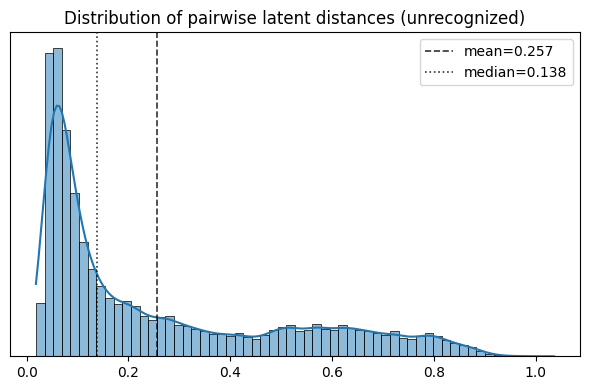

In [65]:
unrec_Z = np.vstack(TP_unrec['latent'].values).astype(np.float32)
D = pairwise_distances(unrec_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 0)

sklearn Latent pairwise stats: {'n_pairs': 258840, 'min': 0.009386186487972736, 'median': 0.03350453823804855, 'mean': 0.04121549054980278, 'p95': 0.07720995210111135}


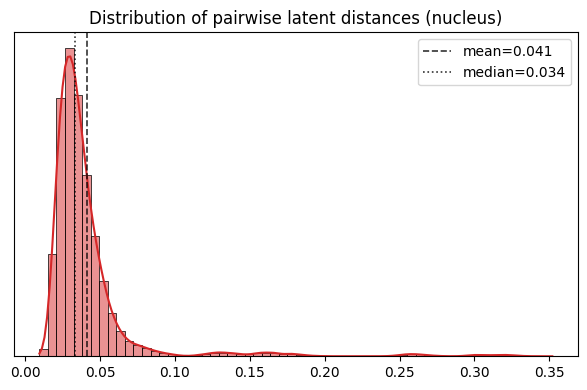

In [66]:
nuc_Z = np.vstack(TP_nuc['latent'].values).astype(np.float32)
D = pairwise_distances(nuc_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 1)

sklearn Latent pairwise stats: {'n_pairs': 203841, 'min': 0.013923739083111286, 'median': 0.0512344054877758, 'mean': 0.06732480973005295, 'p95': 0.16773605346679688}


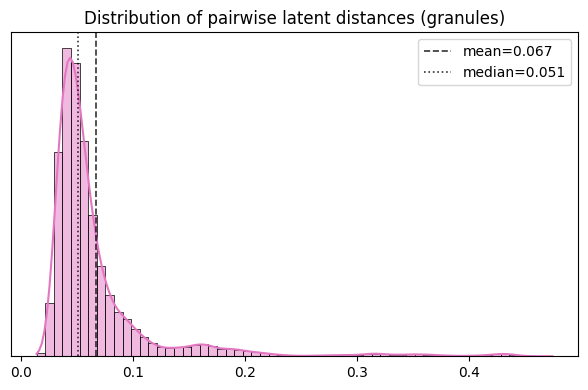

In [67]:
granules_Z = np.vstack(TP_granules['latent'].values).astype(np.float32)
D = pairwise_distances(granules_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 2)

sklearn Latent pairwise stats: {'n_pairs': 148785, 'min': 0.009823460131883621, 'median': 0.04970717802643776, 'mean': 0.061695508658885956, 'p95': 0.12121482640504835}


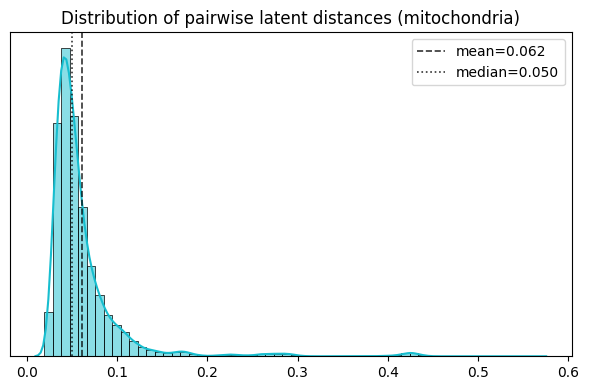

In [68]:
mito_Z = np.vstack(TP_mito['latent'].values).astype(np.float32)
D = pairwise_distances(mito_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 3)

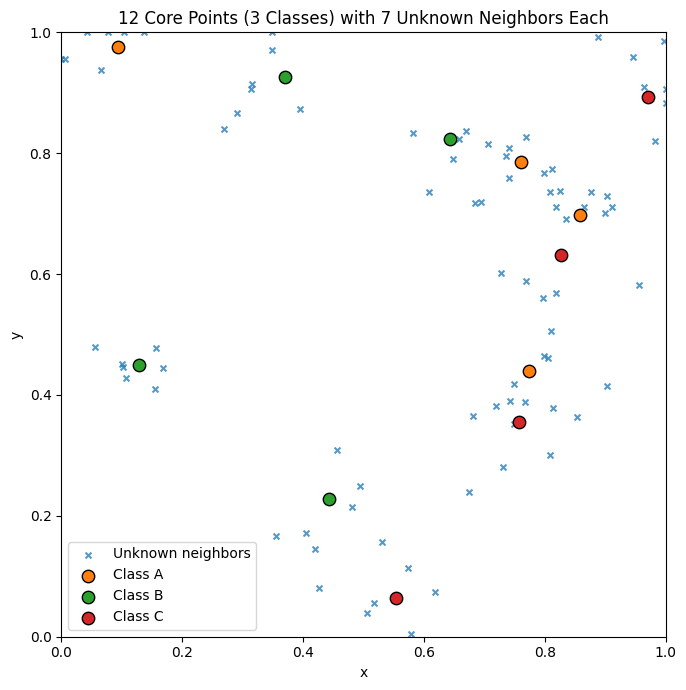

In [69]:
# 2D scatter: 12 core points (3 classes, 4 each) + 7 unknown neighbors around each
# Run: python plot_points_with_neighbors.py  (or just run in a notebook cell)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42      # set to None for different layout each run
NEIGHBOR_SPREAD = 0.06  # std dev of neighbor offsets (in axis units)
SAVE_CSV = False        # set True to save "points_with_neighbors.csv"
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# Core points: 3 classes, 4 points each → 12 total
classes = ["A"] * 4 + ["B"] * 4 + ["C"] * 4
n_core = len(classes)

# Random core locations in [0,1] × [0,1]
core_xy = rng.uniform(0, 1, size=(n_core, 2))

# 7 neighbors around each core (unknown class)
n_neighbors_per_core = 7
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(n_neighbors_per_core, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    # keep neighbors inside the unit square
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny))

# ---- assemble dataframes (optional, handy for saving/inspection) ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y"])
df_neighbors["type"] = "neighbor"
df_neighbors["class"] = "unknown"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ---------------------------- plot -----------------------------
plt.figure(figsize=(7, 7))

# plot unknown neighbors
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.75, label="Unknown neighbors"
)

# plot core points by class (default color cycle)
for cls in ["A", "B", "C"]:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=80, marker="o", edgecolors="black", linewidths=1, label=f"Class {cls}"
    )

plt.title("12 Core Points (3 Classes) with 7 Unknown Neighbors Each")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------- save -----------------------------
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors.csv", index=False)
    print("Saved: points_with_neighbors.csv")


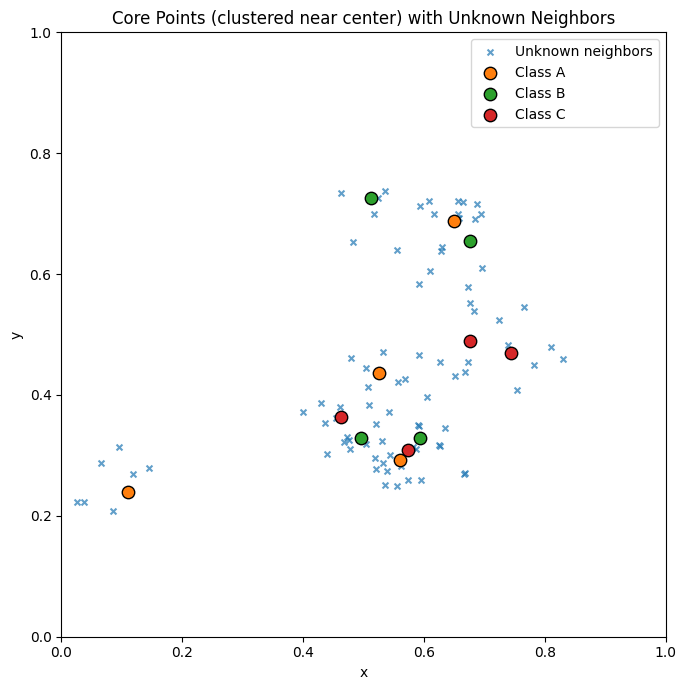

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_SPREAD = 0.2       # smaller → tighter cluster around center (0.5, 0.5)
NEIGHBOR_SPREAD = 0.05  # spread of neighbors around each core point
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# Core points: 3 classes, 4 points each → 12 total
classes = ["A"] * 4 + ["B"] * 4 + ["C"] * 4
n_core = len(classes)

# Core locations sampled around the center (0.5, 0.5)
core_xy = rng.normal(loc=0.5, scale=CORE_SPREAD, size=(n_core, 2))
core_xy = np.clip(core_xy, 0, 1)  # keep inside [0,1]

# 7 neighbors around each core (unknown class)
n_neighbors_per_core = 7
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(n_neighbors_per_core, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny))

# ---- assemble dataframes (optional, handy for saving/inspection) ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y"])
df_neighbors["type"] = "neighbor"
df_neighbors["class"] = "unknown"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ---------------------------- plot -----------------------------
plt.figure(figsize=(7, 7))

# plot unknown neighbors
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.7, label="Unknown neighbors"
)

# plot core points by class (default color cycle)
for cls in ["A", "B", "C"]:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=80, marker="o", edgecolors="black", linewidths=1, label=f"Class {cls}"
    )

plt.title("Core Points (clustered near center) with Unknown Neighbors")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------- save -----------------------------
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors.csv", index=False)
    print("Saved: points_with_neighbors.csv")


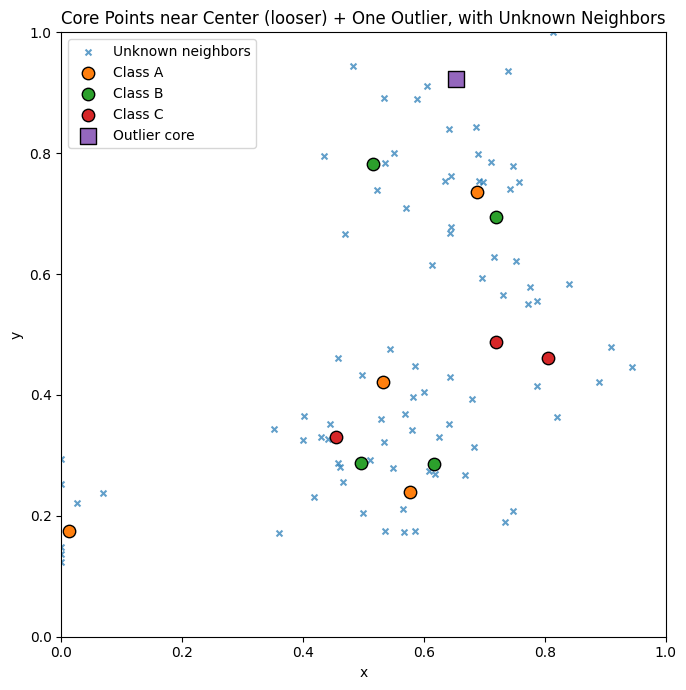

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_SPREAD = 0.25       # larger → looser cluster near center
NEIGHBOR_SPREAD = 0.08   # neighbors spread around each core
OUTLIER_RADIUS = 0.45    # how far from the center the outlier sits (0..~0.7)
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# Core points: 3 classes, 4 points each → 12 total
classes = ["A"] * 4 + ["B"] * 4 + ["C"] * 4
n_core = len(classes)

# 1) Generate cores around the center (looser than before)
core_xy = rng.normal(loc=0.5, scale=CORE_SPREAD, size=(n_core, 2))
core_xy = np.clip(core_xy, 0, 1)

# 2) Force ONE outlier core point, far from the center
# Choose which core becomes the outlier (random index)
outlier_idx = rng.integers(0, n_core)

# Pick a random direction and place the outlier on a ring around center
theta = rng.uniform(0, 2 * np.pi)
# Start from exact center, then push outward by OUTLIER_RADIUS, and clip to [0,1]
outlier = np.array([0.5, 0.5]) + OUTLIER_RADIUS * np.array([np.cos(theta), np.sin(theta)])
outlier = np.clip(outlier, 0, 1)
core_xy[outlier_idx] = outlier

# 7 neighbors around each core (unknown class)
n_neighbors_per_core = 7
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(n_neighbors_per_core, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny))

# ---- assemble dataframes (optional, handy for saving/inspection) ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})
df_core.loc[outlier_idx, "is_outlier"] = True
df_core["is_outlier"].fillna(False, inplace=True)

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y"])
df_neighbors["type"] = "neighbor"
df_neighbors["class"] = "unknown"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ---------------------------- plot -----------------------------
plt.figure(figsize=(7, 7))

# plot unknown neighbors
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.7, label="Unknown neighbors"
)

# plot core points by class; highlight the outlier with a square marker
for cls in ["A", "B", "C"]:
    sub = df_core[(df_core["class"] == cls) & (~df_core["is_outlier"])]
    plt.scatter(
        sub["x"], sub["y"],
        s=80, marker="o", edgecolors="black", linewidths=1, label=f"Class {cls}"
    )

# outlier (keep its class label but draw differently)
out = df_core[df_core["is_outlier"]]
plt.scatter(
    out["x"], out["y"],
    s=140, marker="s", edgecolors="black", linewidths=1, label="Outlier core"
)

plt.title("Core Points near Center (looser) + One Outlier, with Unknown Neighbors")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------- save -----------------------------
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors.csv", index=False)
    print("Saved: points_with_neighbors.csv")


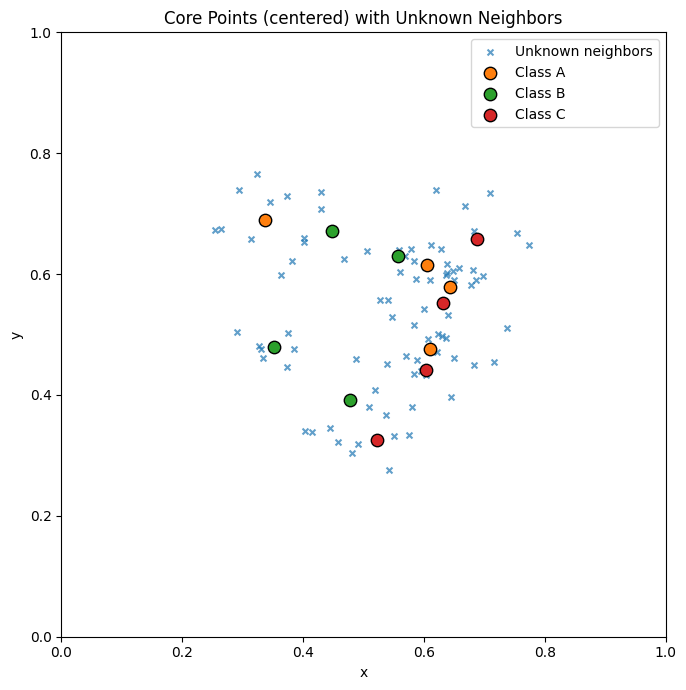

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_RANGE = (0.3, 0.7)   # anchors will be uniformly sampled in this box
NEIGHBOR_SPREAD = 0.05    # spread of neighbors around each core
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# Core points: 3 classes, 4 points each → 12 total
classes = ["A"] * 4 + ["B"] * 4 + ["C"] * 4
n_core = len(classes)

# Generate anchors uniformly within a central box (no outliers)
core_xy = rng.uniform(CORE_RANGE[0], CORE_RANGE[1], size=(n_core, 2))

# 7 neighbors around each core (unknown class)
n_neighbors_per_core = 7
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(n_neighbors_per_core, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny))

# ---- assemble dataframes ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y"])
df_neighbors["type"] = "neighbor"
df_neighbors["class"] = "unknown"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ---------------------------- plot -----------------------------
plt.figure(figsize=(7, 7))

# plot unknown neighbors
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.7, label="Unknown neighbors"
)

# plot core points by class
for cls in ["A", "B", "C"]:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=80, marker="o", edgecolors="black", linewidths=1, label=f"Class {cls}"
    )

plt.title("Core Points (centered) with Unknown Neighbors")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------- save -----------------------------
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors.csv", index=False)
    print("Saved: points_with_neighbors.csv")


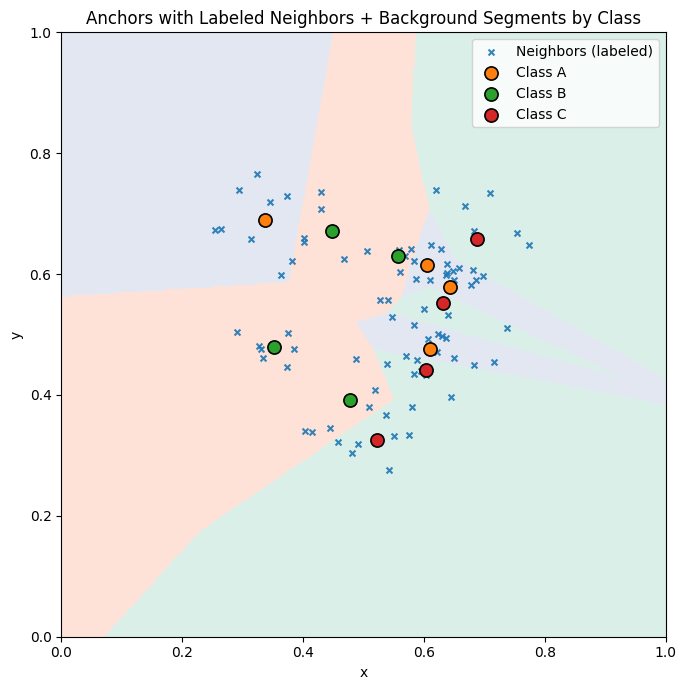

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_RANGE = (0.3, 0.7)   # anchors are uniformly sampled in this central box
N_CLASSES = 3
POINTS_PER_CLASS = 4      # 12 total anchors = 3 * 4
N_NEIGHBORS_PER_ANCHOR = 7
NEIGHBOR_SPREAD = 0.05    # std-dev of neighbor offsets
GRID_RES = 400            # background segmentation resolution (higher = smoother)
BG_ALPHA = 0.25           # transparency of background segments
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# ----- anchors/classes -----
classes = sum([[c] * POINTS_PER_CLASS for c in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:N_CLASSES]], [])
n_core = len(classes)  # should be N_CLASSES * POINTS_PER_CLASS

# anchors in central box (no outliers)
core_xy = rng.uniform(CORE_RANGE[0], CORE_RANGE[1], size=(n_core, 2))

# ----- neighbors: inherit the label of their anchoring core -----
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(N_NEIGHBORS_PER_ANCHOR, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny, classes[core_id]))

# ---- dataframes (optional; handy for saving/inspection) ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y", "class"])
df_neighbors["type"] = "neighbor"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ----- background segmentation (Voronoi-by-class via nearest core) -----
# Build a grid over [0,1]x[0,1]
xs = np.linspace(0, 1, GRID_RES)
ys = np.linspace(0, 1, GRID_RES)
gx, gy = np.meshgrid(xs, ys)
grid = np.stack([gx, gy], axis=-1)  # (H, W, 2)

# distances from each grid point to each core
# reshape to (H*W, 2) vs (n_core, 2)
grid_flat = grid.reshape(-1, 2)                # (H*W, 2)
cores = core_xy[None, :, :]                    # (1, n_core, 2)
grid_expanded = grid_flat[:, None, :]          # (H*W, 1, 2)
d2 = np.sum((grid_expanded - cores) ** 2, axis=-1)  # (H*W, n_core)

nearest_core_idx = np.argmin(d2, axis=1)       # (H*W,)
nearest_class = np.array([classes[i] for i in nearest_core_idx])
# map class letters to integers for imshow
unique_classes = sorted(list(set(classes)))
class_to_int = {c: i for i, c in enumerate(unique_classes)}
bg_int = np.vectorize(class_to_int.get)(nearest_class).reshape(GRID_RES, GRID_RES)

# ----- plotting -----
plt.figure(figsize=(7, 7))

# background: use a discrete colormap with as many colors as classes
from matplotlib.colors import ListedColormap
# pick a small palette; feel free to change hexes
palette = ["#8da0cb", "#fc8d62", "#66c2a5", "#e78ac3", "#a6d854", "#ffd92f"]
cmap = ListedColormap(palette[:len(unique_classes)])

plt.imshow(
    bg_int,
    origin="lower",
    extent=[0, 1, 0, 1],
    interpolation="nearest",
    cmap=cmap,
    alpha=BG_ALPHA
)

# plot neighbors (now labeled)
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.9, label="Neighbors (labeled)"
)

# plot anchors by class, outlined
for cls in unique_classes:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=90, marker="o", edgecolors="black", linewidths=1.2, label=f"Class {cls}"
    )

plt.title("Anchors with Labeled Neighbors + Background Segments by Class")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# ----- save if desired -----
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors_and_bg.csv", index=False)
    print("Saved: points_with_neighbors_and_bg.csv")


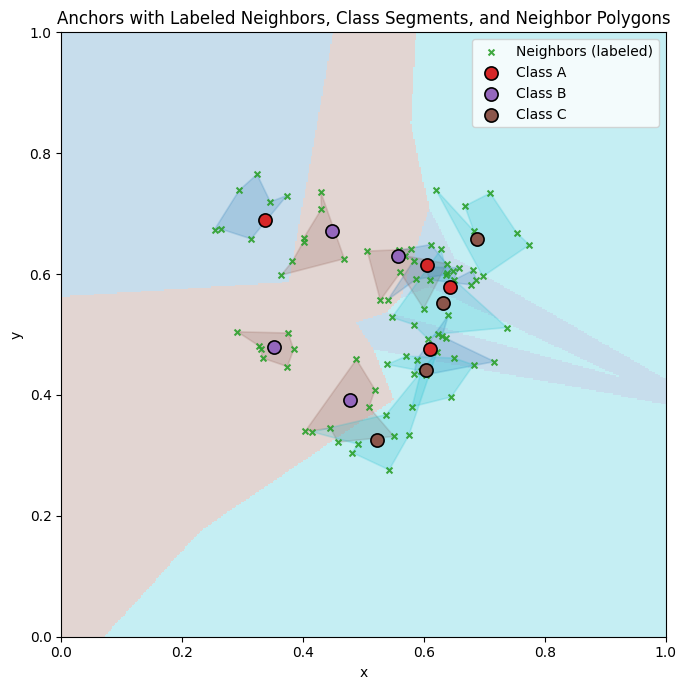

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_RANGE = (0.3, 0.7)      # anchors uniformly sampled in this box (keeps them central)
N_CLASSES = 3
POINTS_PER_CLASS = 4         # 12 anchors total
N_NEIGHBORS_PER_ANCHOR = 7
NEIGHBOR_SPREAD = 0.05       # std-dev of neighbor offsets
GRID_RES = 400               # background segmentation resolution
BG_ALPHA = 0.25              # opacity for background segments
POLY_ALPHA = 0.2             # fill opacity for neighbor polygons
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# ----- anchors/classes -----
classes = sum([[c] * POINTS_PER_CLASS for c in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:N_CLASSES]], [])
n_core = len(classes)

# anchors in central box (no outliers)
core_xy = rng.uniform(CORE_RANGE[0], CORE_RANGE[1], size=(n_core, 2))

# ----- neighbors inherit the anchor's class -----
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(N_NEIGHBORS_PER_ANCHOR, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny, classes[core_id]))

# ---- dataframes (optional for saving/inspection) ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y", "class"])
df_neighbors["type"] = "neighbor"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ----- background segmentation (nearest-anchor class) -----
xs = np.linspace(0, 1, GRID_RES)
ys = np.linspace(0, 1, GRID_RES)
gx, gy = np.meshgrid(xs, ys)
grid_flat = np.stack([gx.ravel(), gy.ravel()], axis=-1)  # (H*W, 2)

d2 = ((grid_flat[:, None, :] - core_xy[None, :, :]) ** 2).sum(axis=-1)  # (H*W, n_core)
nearest_core_idx = np.argmin(d2, axis=1)
nearest_class = np.array([classes[i] for i in nearest_core_idx])

unique_classes = sorted(set(classes))
class_to_int = {c: i for i, c in enumerate(unique_classes)}
bg_int = np.vectorize(class_to_int.get)(nearest_class).reshape(GRID_RES, GRID_RES)

# discrete colormap for classes
cmap = plt.cm.get_cmap("tab10", len(unique_classes))

# ----- plotting -----
plt.figure(figsize=(7, 7))

# background segments
plt.imshow(
    bg_int, origin="lower", extent=[0, 1, 0, 1],
    interpolation="nearest", cmap=cmap, alpha=BG_ALPHA
)

# draw neighbor polygons per anchor (order neighbors by angle around anchor)
for core_id, row in df_core.iterrows():
    cx, cy = row["x"], row["y"]
    sub = df_neighbors[df_neighbors["core_id"] == core_id][["x", "y"]].to_numpy()
    # compute angles relative to the anchor, sort CCW
    angles = np.arctan2(sub[:, 1] - cy, sub[:, 0] - cx)
    order = np.argsort(angles)
    poly = sub[order]

    # color by the class of the anchor
    cls = row["class"]
    color = cmap(class_to_int[cls])

    # fill and outline polygon
    plt.fill(poly[:, 0], poly[:, 1], alpha=POLY_ALPHA, facecolor=color, edgecolor=color, linewidth=1.2)

# plot neighbors (labeled, as x markers)
plt.scatter(
    df_neighbors["x"], df_neighbors["y"],
    s=18, marker="x", alpha=0.9, label="Neighbors (labeled)"
)

# plot anchors per class (outlined circles)
for cls in unique_classes:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=90, marker="o", edgecolors="black", linewidths=1.2, label=f"Class {cls}"
    )

plt.title("Anchors with Labeled Neighbors, Class Segments, and Neighbor Polygons")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
# Build a clean legend with unique handles
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# ----- save (optional) -----
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors_polygons.csv", index=False)
    print("Saved: points_with_neighbors_polygons.csv")


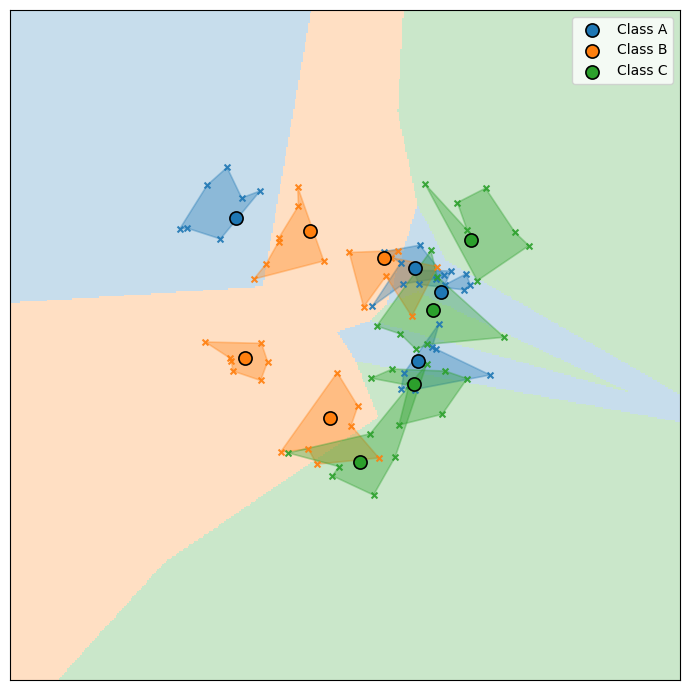

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_RANGE = (0.3, 0.7)      # anchors uniformly sampled in this box
N_CLASSES = 3
POINTS_PER_CLASS = 4         # 12 anchors total
N_NEIGHBORS_PER_ANCHOR = 7
NEIGHBOR_SPREAD = 0.05       # std-dev of neighbor offsets
GRID_RES = 400               # resolution for background segmentation
BG_ALPHA = 0.25              # background opacity
POLY_ALPHA = 0.35            # fill opacity for neighbor polygons
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# ----- anchors/classes -----
classes = sum([[c] * POINTS_PER_CLASS for c in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:N_CLASSES]], [])
n_core = len(classes)

# anchors in central box
core_xy = rng.uniform(CORE_RANGE[0], CORE_RANGE[1], size=(n_core, 2))

# ----- neighbors (inherit anchor's class) -----
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(N_NEIGHBORS_PER_ANCHOR, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny, classes[core_id]))

# ---- dataframes ----
df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y", "class"])
df_neighbors["type"] = "neighbor"

df_all = pd.concat([df_core, df_neighbors], ignore_index=True)

# ----- class color map -----
unique_classes = sorted(set(classes))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]  # extend if needed
cmap = ListedColormap(palette[:len(unique_classes)])
class_to_int = {c: i for i, c in enumerate(unique_classes)}

# ----- background segmentation (Voronoi-like by nearest anchor) -----
xs = np.linspace(0, 1, GRID_RES)
ys = np.linspace(0, 1, GRID_RES)
gx, gy = np.meshgrid(xs, ys)
grid_flat = np.stack([gx.ravel(), gy.ravel()], axis=-1)  # (H*W, 2)

d2 = ((grid_flat[:, None, :] - core_xy[None, :, :]) ** 2).sum(axis=-1)  # (H*W, n_core)
nearest_core_idx = np.argmin(d2, axis=1)
nearest_class = np.array([classes[i] for i in nearest_core_idx])
bg_int = np.vectorize(class_to_int.get)(nearest_class).reshape(GRID_RES, GRID_RES)

# ----- plotting -----
plt.figure(figsize=(7, 7))

# background
plt.imshow(
    bg_int, origin="lower", extent=[0, 1, 0, 1],
    interpolation="nearest", cmap=cmap, alpha=BG_ALPHA
)

# polygons per anchor
for core_id, row in df_core.iterrows():
    cx, cy = row["x"], row["y"]
    sub = df_neighbors[df_neighbors["core_id"] == core_id][["x", "y"]].to_numpy()
    # order neighbors CCW around anchor
    angles = np.arctan2(sub[:, 1] - cy, sub[:, 0] - cx)
    order = np.argsort(angles)
    poly = sub[order]

    cls = row["class"]
    color = cmap(class_to_int[cls])

    plt.fill(poly[:, 0], poly[:, 1], alpha=POLY_ALPHA, facecolor=color, edgecolor=color, linewidth=1.2)

# neighbors (as x markers, same class color)
for cls in unique_classes:
    sub = df_neighbors[df_neighbors["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=18, marker="x", alpha=0.9, color=cmap(class_to_int[cls])
    )

# anchors (as circles, same class color but outlined black)
for cls in unique_classes:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=90, marker="o", color=cmap(class_to_int[cls]),
        edgecolors="black", linewidths=1.2, label=f"Class {cls}"
    )

# plt.title("Anchors, Neighbors, Polygons, and Background (Unified Colors)")
# plt.xlabel("x")
# plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# ----- save -----
if SAVE_CSV:
    df_all.to_csv("points_with_neighbors_polygons_colors.csv", index=False)
    print("Saved: points_with_neighbors_polygons_colors.csv")


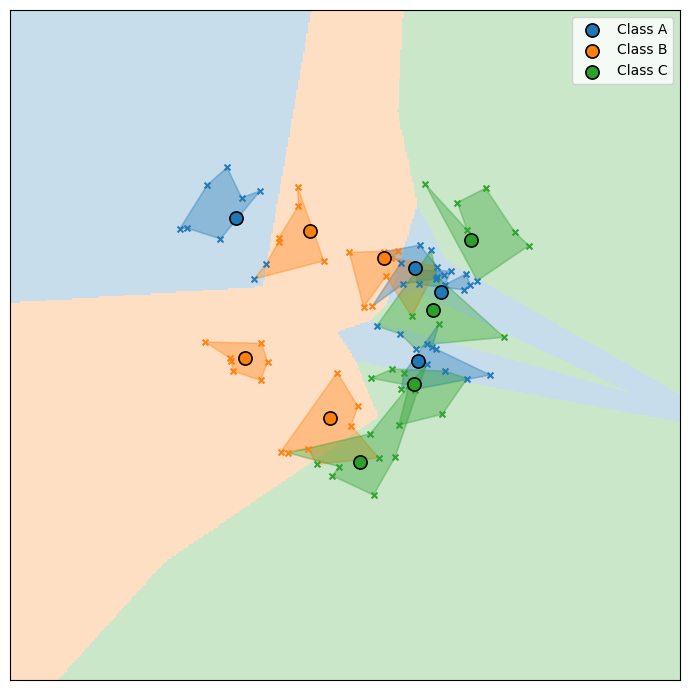

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

# ---------------------- configurable bits ----------------------
RANDOM_SEED = 42
CORE_RANGE = (0.3, 0.7)      # anchors uniformly sampled in this box
N_CLASSES = 3
POINTS_PER_CLASS = 4         # 12 anchors total
N_NEIGHBORS_PER_ANCHOR = 7
NEIGHBOR_SPREAD = 0.05       # std-dev of neighbor offsets
GRID_RES = 400               # resolution for background segmentation
BG_ALPHA = 0.25              # background opacity
POLY_ALPHA = 0.35            # polygon fill opacity
SAVE_CSV = False
# ---------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

# ----- anchors/classes -----
classes = sum([[c] * POINTS_PER_CLASS for c in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:N_CLASSES]], [])
n_core = len(classes)

# anchors in central box
core_xy = rng.uniform(CORE_RANGE[0], CORE_RANGE[1], size=(n_core, 2))

# ----- neighbors (initially inherit anchor id, but display color will be by background segment) -----
neighbors = []
for core_id, (x, y) in enumerate(core_xy):
    offsets = rng.normal(0.0, NEIGHBOR_SPREAD, size=(N_NEIGHBORS_PER_ANCHOR, 2))
    neigh_xy = np.column_stack([x + offsets[:, 0], y + offsets[:, 1]])
    neigh_xy = np.clip(neigh_xy, 0, 1)
    for (nx, ny) in neigh_xy:
        neighbors.append((core_id, nx, ny, classes[core_id]))

df_core = pd.DataFrame({
    "core_id": np.arange(n_core),
    "x": core_xy[:, 0],
    "y": core_xy[:, 1],
    "type": "core",
    "class": classes
})

df_neighbors = pd.DataFrame(neighbors, columns=["core_id", "x", "y", "anchor_class"])
df_neighbors["type"] = "neighbor"

# ----- class color map -----
unique_classes = sorted(set(classes))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]  # extend if needed
cmap = ListedColormap(palette[:len(unique_classes)])
class_to_int = {c: i for i, c in enumerate(unique_classes)}

# ----- background segmentation (nearest-anchor class) -----
xs = np.linspace(0, 1, GRID_RES)
ys = np.linspace(0, 1, GRID_RES)
gx, gy = np.meshgrid(xs, ys)
grid_flat = np.stack([gx.ravel(), gy.ravel()], axis=-1)  # (H*W, 2)

d2 = ((grid_flat[:, None, :] - core_xy[None, :, :]) ** 2).sum(axis=-1)  # (H*W, n_core)
nearest_core_idx = np.argmin(d2, axis=1)
nearest_class = np.array([classes[i] for i in nearest_core_idx])
bg_int = np.vectorize(class_to_int.get)(nearest_class).reshape(GRID_RES, GRID_RES)

# For each neighbor: color by the background class at its location (i.e., nearest core overall)
# Compute distances from each neighbor to all cores and take nearest
nbr_xy = df_neighbors[["x", "y"]].to_numpy()  # (N_nbr, 2)
nbr_d2 = ((nbr_xy[:, None, :] - core_xy[None, :, :]) ** 2).sum(axis=-1)  # (N_nbr, n_core)
nbr_nearest_core = np.argmin(nbr_d2, axis=1)
nbr_seg_class = np.array([classes[i] for i in nbr_nearest_core])
df_neighbors["seg_class"] = nbr_seg_class
df_neighbors["seg_class_idx"] = [class_to_int[c] for c in nbr_seg_class]

# ----- plotting -----
plt.figure(figsize=(7, 7))

# background
plt.imshow(
    bg_int, origin="lower", extent=[0, 1, 0, 1],
    interpolation="nearest", cmap=cmap, alpha=BG_ALPHA
)

# polygons per anchor (colored by anchor class)
for core_id, row in df_core.iterrows():
    cx, cy = row["x"], row["y"]
    sub = df_neighbors[df_neighbors["core_id"] == core_id][["x", "y"]].to_numpy()
    # order neighbors CCW around anchor
    angles = np.arctan2(sub[:, 1] - cy, sub[:, 0] - cx)
    order = np.argsort(angles)
    poly = sub[order]

    cls = row["class"]
    color = cmap(class_to_int[cls])

    plt.fill(poly[:, 0], poly[:, 1], alpha=POLY_ALPHA, facecolor=color, edgecolor=color, linewidth=1.2)

# neighbors (colored by the background segment they fall into)
for cls in unique_classes:
    sub = df_neighbors[df_neighbors["seg_class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=18, marker="x", alpha=0.95, color=cmap(class_to_int[cls]),
        label=None
    )

# anchors (colored by their own class, outlined black)
for cls in unique_classes:
    sub = df_core[df_core["class"] == cls]
    plt.scatter(
        sub["x"], sub["y"],
        s=90, marker="o", color=cmap(class_to_int[cls]),
        edgecolors="black", linewidths=1.2, label=f"Class {cls}"
    )

# plt.title("Unified Colors: Background & Neighbors by Segment; Polygons & Anchors by Anchor Class")
# plt.xlabel("x")
# plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks([])
plt.yticks([])

plt.gca().set_aspect("equal", adjustable="box")

# Legend for classes (anchors)
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# ----- save (optional) -----
if SAVE_CSV:
    df = pd.concat([df_core.assign(kind="anchor"), df_neighbors.assign(kind="neighbor")], ignore_index=True)
    df.to_csv("points_with_neighbors_polygons_segment_colored_neighbors.csv", index=False)
    print("Saved: points_with_neighbors_polygons_segment_colored_neighbors.csv")
